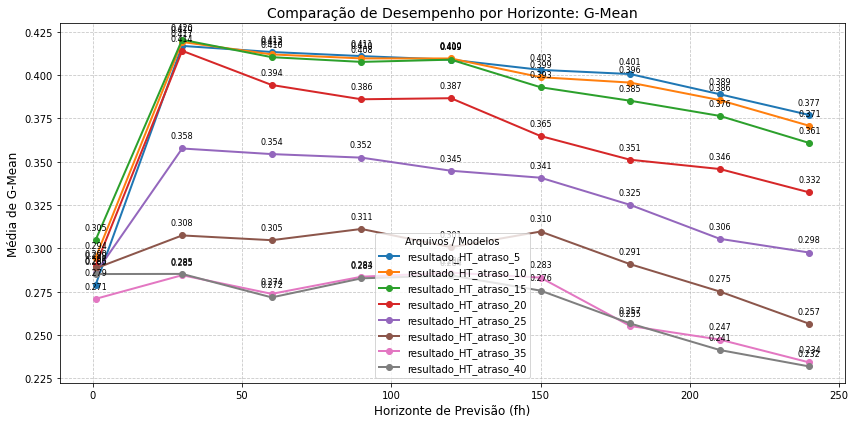

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import os

# ==============================================================================
# LENDO OS ARQUIVOS E PLOTANDO O GRÁFICO
# ==============================================================================

# 1. Configurações
metrica_escolhida = 'G-Mean' # Pode trocar por 'Kappa', 'AUC', 'profit', etc.
modelo = 'HT'  # Nome do modelo para o título do gráfico
categoria = 'nao_fund'  # Categoria a ser filtrada nos dados
atrasos = [5, 10, 15, 20, 25, 30, 35, 40]
plt.figure(figsize=(12, 6))

# 2. Loop para processar cada arquivo
for atraso in atrasos:
    try:
        # Lê o csv
        df = pd.read_csv(f'resultados/resultados_{modelo}_atraso_{atraso}.csv')
        df =  df[df['categoria'] == categoria]  
        arquivo = f'resultado_{modelo}_atraso_{atraso}.csv'
        # Verifica se as colunas necessárias existem
        if 'fh' not in df.columns or metrica_escolhida not in df.columns:
            print(f"Aviso: Arquivo {arquivo} não tem as colunas 'fh' ou '{metrica_escolhida}'. Pulando.")
            continue
            
        # Agrupa por Horizonte (fh) e calcula a média da métrica
        # Isso é importante pois, no seu exemplo, há várias ações (base) para o mesmo fh.
        # Queremos o desempenho médio do modelo naquele horizonte.
        df_agrupado = df.groupby('fh')[metrica_escolhida].mean().sort_index()
        
        # Plota a linha deste arquivo
        # O label será o nome do arquivo (removemos o .csv para ficar bonito)
        nome_legenda = os.path.splitext(os.path.basename(arquivo))[0]
        
        plt.plot(df_agrupado.index, df_agrupado.values, marker='o', linewidth=2, label=nome_legenda)
        
        # Adiciona anotação de valor no gráfico (opcional)
        for x, y in zip(df_agrupado.index, df_agrupado.values):
            plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    except Exception as e:
        print(f"Erro ao processar o arquivo {arquivo}: {e}")

# 3. Estilização do Gráfico
plt.title(f'Comparação de Desempenho por Horizonte: {metrica_escolhida}', fontsize=14)
plt.xlabel('Horizonte de Previsão (fh)', fontsize=12)
plt.ylabel(f'Média de {metrica_escolhida}', fontsize=12)

# Garante que o eixo X mostre os horizontes corretamente (ex: 1, 30, 60...)
# Se quiser forçar apenas os horizontes que existem nos dados:
# plt.xticks(df_agrupado.index) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Arquivos / Modelos")
plt.tight_layout()

# Mostrar o gráfico
plt.show()

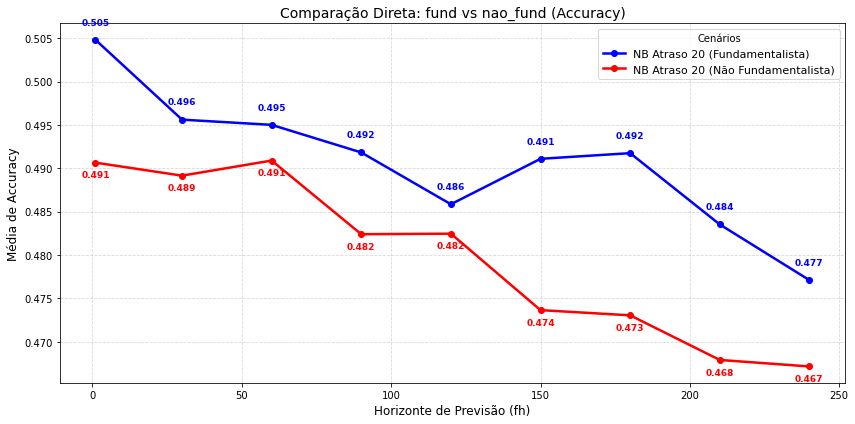

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================================================================
# CONFIGURAÇÕES DA COMPARAÇÃO
# ==============================================================================

metrica_escolhida = 'Accuracy' # Ex: 'Kappa', 'AUC', 'profit', 'Accuracy'

# --- Configuração do 1º Caso ---
config_1 = {
    'modelo': 'NB',
    'atraso': 20,            # Defina qual arquivo carregar
    'categoria': 'fund',    # 'fund' ou 'nao_fund'
    'legenda': 'NB Atraso 20 (Fundamentalista)',
    'cor': 'blue'
}

# --- Configuração do 2º Caso ---
config_2 = {
    'modelo': 'NB',         # Pode ser o mesmo modelo ou outro
    'atraso': 20,            # Pode ser o mesmo arquivo ou outro
    'categoria': 'nao_fund',# 'fund' ou 'nao_fund'
    'legenda': 'NB Atraso 20 (Não Fundamentalista)',
    'cor': 'red'
}

# Lista para iterar (facilita se quiser adicionar mais casos no futuro)
casos_para_comparar = [config_1, config_2]

# ==============================================================================
# PROCESSAMENTO E PLOTAGEM
# ==============================================================================

plt.figure(figsize=(12, 6))

for config in casos_para_comparar:
    # Constrói o nome do arquivo baseado no modelo e atraso definidos
    nome_arquivo = f"resultados/resultados_{config['modelo']}_atraso_{config['atraso']}.csv"
    
    try:
        # 1. Leitura
        if not os.path.exists(nome_arquivo):
            print(f"ERRO: O arquivo '{nome_arquivo}' não foi encontrado.")
            continue
            
        df = pd.read_csv(nome_arquivo)
        
        # 2. Verifica colunas
        if 'fh' not in df.columns or metrica_escolhida not in df.columns or 'categoria' not in df.columns:
            print(f"AVISO: Arquivo '{nome_arquivo}' não possui as colunas necessárias. Pulando.")
            continue

        # 3. Filtragem pela Categoria escolhida
        df_filtrado = df[df['categoria'] == config['categoria']].copy()
        
        if df_filtrado.empty:
            print(f"AVISO: Não há dados para a categoria '{config['categoria']}' no arquivo '{nome_arquivo}'.")
            continue

        # 4. Agrupamento (Média por Horizonte)
        df_agrupado = df_filtrado.groupby('fh')[metrica_escolhida].mean().sort_index()
        
        # 5. Plotagem
        plt.plot(df_agrupado.index, 
                 df_agrupado.values, 
                 marker='o', 
                 linewidth=2.5, 
                 label=config['legenda'],
                 color=config.get('cor'))
        
        # Adiciona anotação de valor no gráfico
        for x, y in zip(df_agrupado.index, df_agrupado.values):
            # Pequeno ajuste na posição do texto para não sobrepor (se for o 2º caso, coloca texto para baixo)
            offset = 15 if config == config_1 else -15 
            plt.annotate(f'{y:.3f}', 
                         (x, y), 
                         textcoords="offset points", 
                         xytext=(0, offset), 
                         ha='center', 
                         fontsize=9,
                         fontweight='bold',
                         color=config.get('cor'))

    except Exception as e:
        print(f"Erro inesperado ao processar '{config['legenda']}': {e}")

# ==============================================================================
# ESTILIZAÇÃO FINAL
# ==============================================================================
plt.title(f'Comparação Direta: {config_1["categoria"]} vs {config_2["categoria"]} ({metrica_escolhida})', fontsize=14)
plt.xlabel('Horizonte de Previsão (fh)', fontsize=12)
plt.ylabel(f'Média de {metrica_escolhida}', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Cenários", fontsize=11)

# Ajuste automático das margens
plt.tight_layout()

plt.show()

Lendo dados...


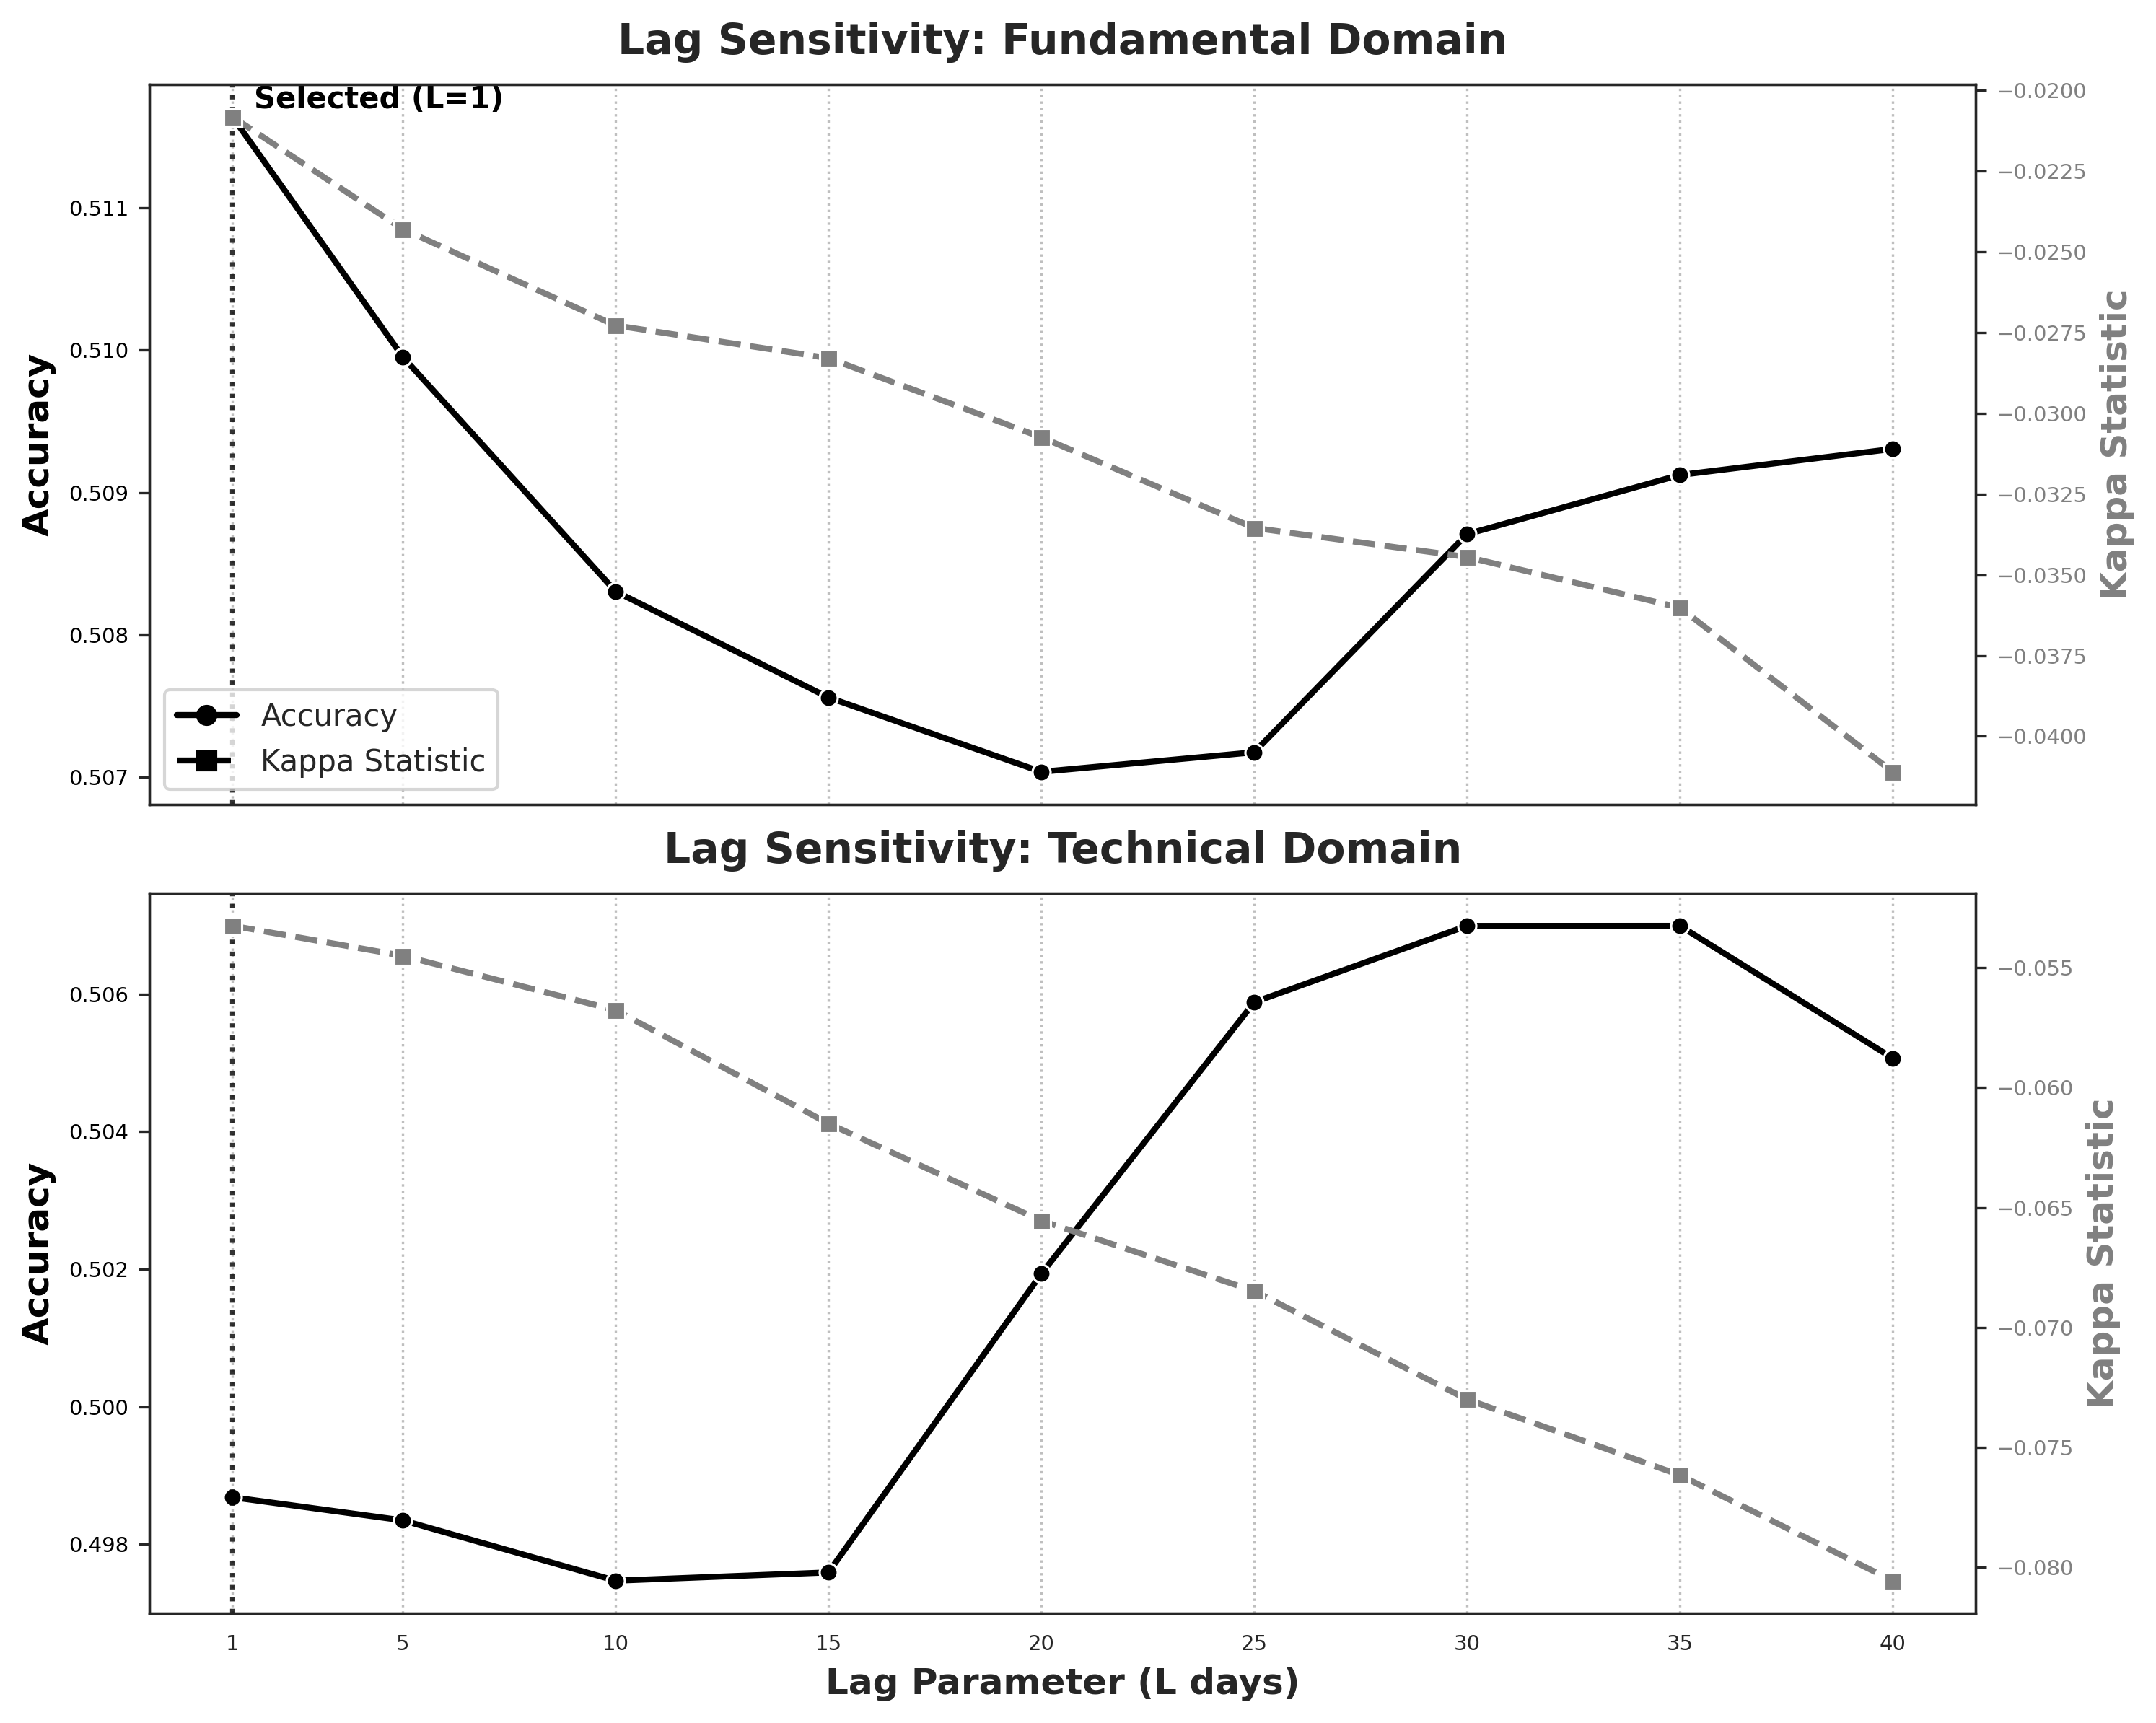

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atrasos = [1, 5, 10, 15, 20, 25, 30, 35, 40]
caminho_base = 'resultados'
LAG_SELECIONADO = 1 

# Cores Pretas para Publicação
cor_acc = 'black'       
cor_kap = 'grey'       
cor_destaque = 'black'
cor_baseline = 'black'

mapa_nomes = {'fund': 'Fundamental Domain', 'nao_fund': 'Technical Domain'}
dados_agregados = []

# ==============================================================================
# 2. PROCESSAMENTO DE DADOS
# ==============================================================================
print(f"Lendo dados...")
for atraso in atrasos:
    nome_arquivo = f'resultados_{modelo}_atraso_{atraso}.csv'
    caminho_completo = os.path.join(caminho_base, nome_arquivo)
    try:
        if not os.path.exists(caminho_completo): continue
        df = pd.read_csv(caminho_completo)
        for cat_codigo, cat_nome in mapa_nomes.items():
            df_filtrado = df[df['categoria'] == cat_codigo]
            if not df_filtrado.empty:
                dados_agregados.append({
                    'Lag_Int': atraso,
                    'Domain': cat_nome,
                    'Accuracy': df_filtrado['Accuracy'].mean(),
                    'Kappa': df_filtrado['Kappa'].mean()
                })
    except: pass

if not dados_agregados:
    print("ERRO: Sem dados.")
    exit()

df_plot = pd.DataFrame(dados_agregados).sort_values('Lag_Int')

# ==============================================================================
# 3. PLOTAGEM
# ==============================================================================
sns.set_style("white") 
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, dpi=300)

def plot_grayscale_dual_axis(ax_primary, data, title):
    # Eixo Esquerda (Acurácia)
    sns.lineplot(data=data, x='Lag_Int', y='Accuracy', ax=ax_primary, 
                 color=cor_acc, marker='o', markersize=6, linewidth=2, legend=False)
    
    ax_primary.set_ylabel('Accuracy', color=cor_acc, fontweight='bold', fontsize=12)
    ax_primary.tick_params(axis='y', labelcolor=cor_acc)
    ax_primary.grid(True, axis='x', linestyle=':', color='gray', alpha=0.5) 
    
    # Eixo Direita (Kappa)
    ax_secondary = ax_primary.twinx() 
    sns.lineplot(data=data, x='Lag_Int', y='Kappa', ax=ax_secondary, 
                 color="grey", marker='s', markersize=6, linewidth=2, 
                 linestyle='--', legend=False)
    
    ax_secondary.set_ylabel('Kappa Statistic', color=cor_kap, fontweight='bold', fontsize=12)
    ax_secondary.tick_params(axis='y', labelcolor=cor_kap)
    
    # Referências
    ax_primary.set_title(title, fontsize=14, fontweight='bold', pad=10)
    # ax_secondary.axhline(0, color=cor_baseline, linewidth=1.0, linestyle=' ', alpha=1.0)
    ax_primary.axvline(x=LAG_SELECIONADO, color=cor_destaque, linestyle=':', linewidth=1.5, alpha=0.8)
    
    return ax_secondary

# PLOT 1: FUNDAMENTAL
data_fund = df_plot[df_plot['Domain'] == 'Fundamental Domain']
plot_grayscale_dual_axis(ax_top, data_fund, 'Lag Sensitivity: Fundamental Domain')

y_min, y_max = ax_top.get_ylim()
ax_top.text(LAG_SELECIONADO + 0.5, y_max, f"Selected (L={LAG_SELECIONADO})", 
            color=cor_destaque, fontsize=10, va='top', fontweight='bold')

# PLOT 2: TÉCNICO
data_tech = df_plot[df_plot['Domain'] == 'Technical Domain']
plot_grayscale_dual_axis(ax_bottom, data_tech, 'Lag Sensitivity: Technical Domain')

ax_bottom.set_xlabel('Lag Parameter (L days)', fontsize=12, fontweight='bold')
ax_bottom.set_xticks(atrasos)

# ==============================================================================
# 4. LEGENDA INTERNA (AJUSTADA)
# ==============================================================================
legend_elements = [
    Line2D([0], [0], color='black', lw=2, marker='o', markersize=6, label='Accuracy'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', marker='s', markersize=6, label='Kappa Statistic')
]

# loc='best' tenta encontrar automaticamente o lugar com menos sobreposição de dados.
# frameon=True cria uma caixinha branca atrás da legenda para garantir leitura.
ax_top.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()
NOME_ARQUIVO_SAIDA = f'lag_sensitivity_{modelo}.pdf'
plt.savefig(NOME_ARQUIVO_SAIDA, format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Processando dados dos lags...

RELATÓRIO DETALHADO: ACCURACY E KAPPA POR LAG
             Domain  Lag  Ativos_Count  Accuracy_Exact  Kappa_Exact
 Fundamental Domain    1            58         0.51053     -0.02269
 Fundamental Domain    5            58         0.50839     -0.02717
 Fundamental Domain   10            58         0.50645     -0.03082
 Fundamental Domain   15            58         0.50579     -0.03183
 Fundamental Domain   20            58         0.50525     -0.03466
 Fundamental Domain   25            58         0.50543     -0.03694
 Fundamental Domain   30            58         0.50713     -0.03718
 Fundamental Domain   35            58         0.50740     -0.03884
 Fundamental Domain   40            58         0.50719     -0.04493
   Technical Domain    1            58         0.49881     -0.05155
   Technical Domain    5            58         0.49821     -0.05326
   Technical Domain   10            58         0.49743     -0.05538
   Technical Domain   15            58 

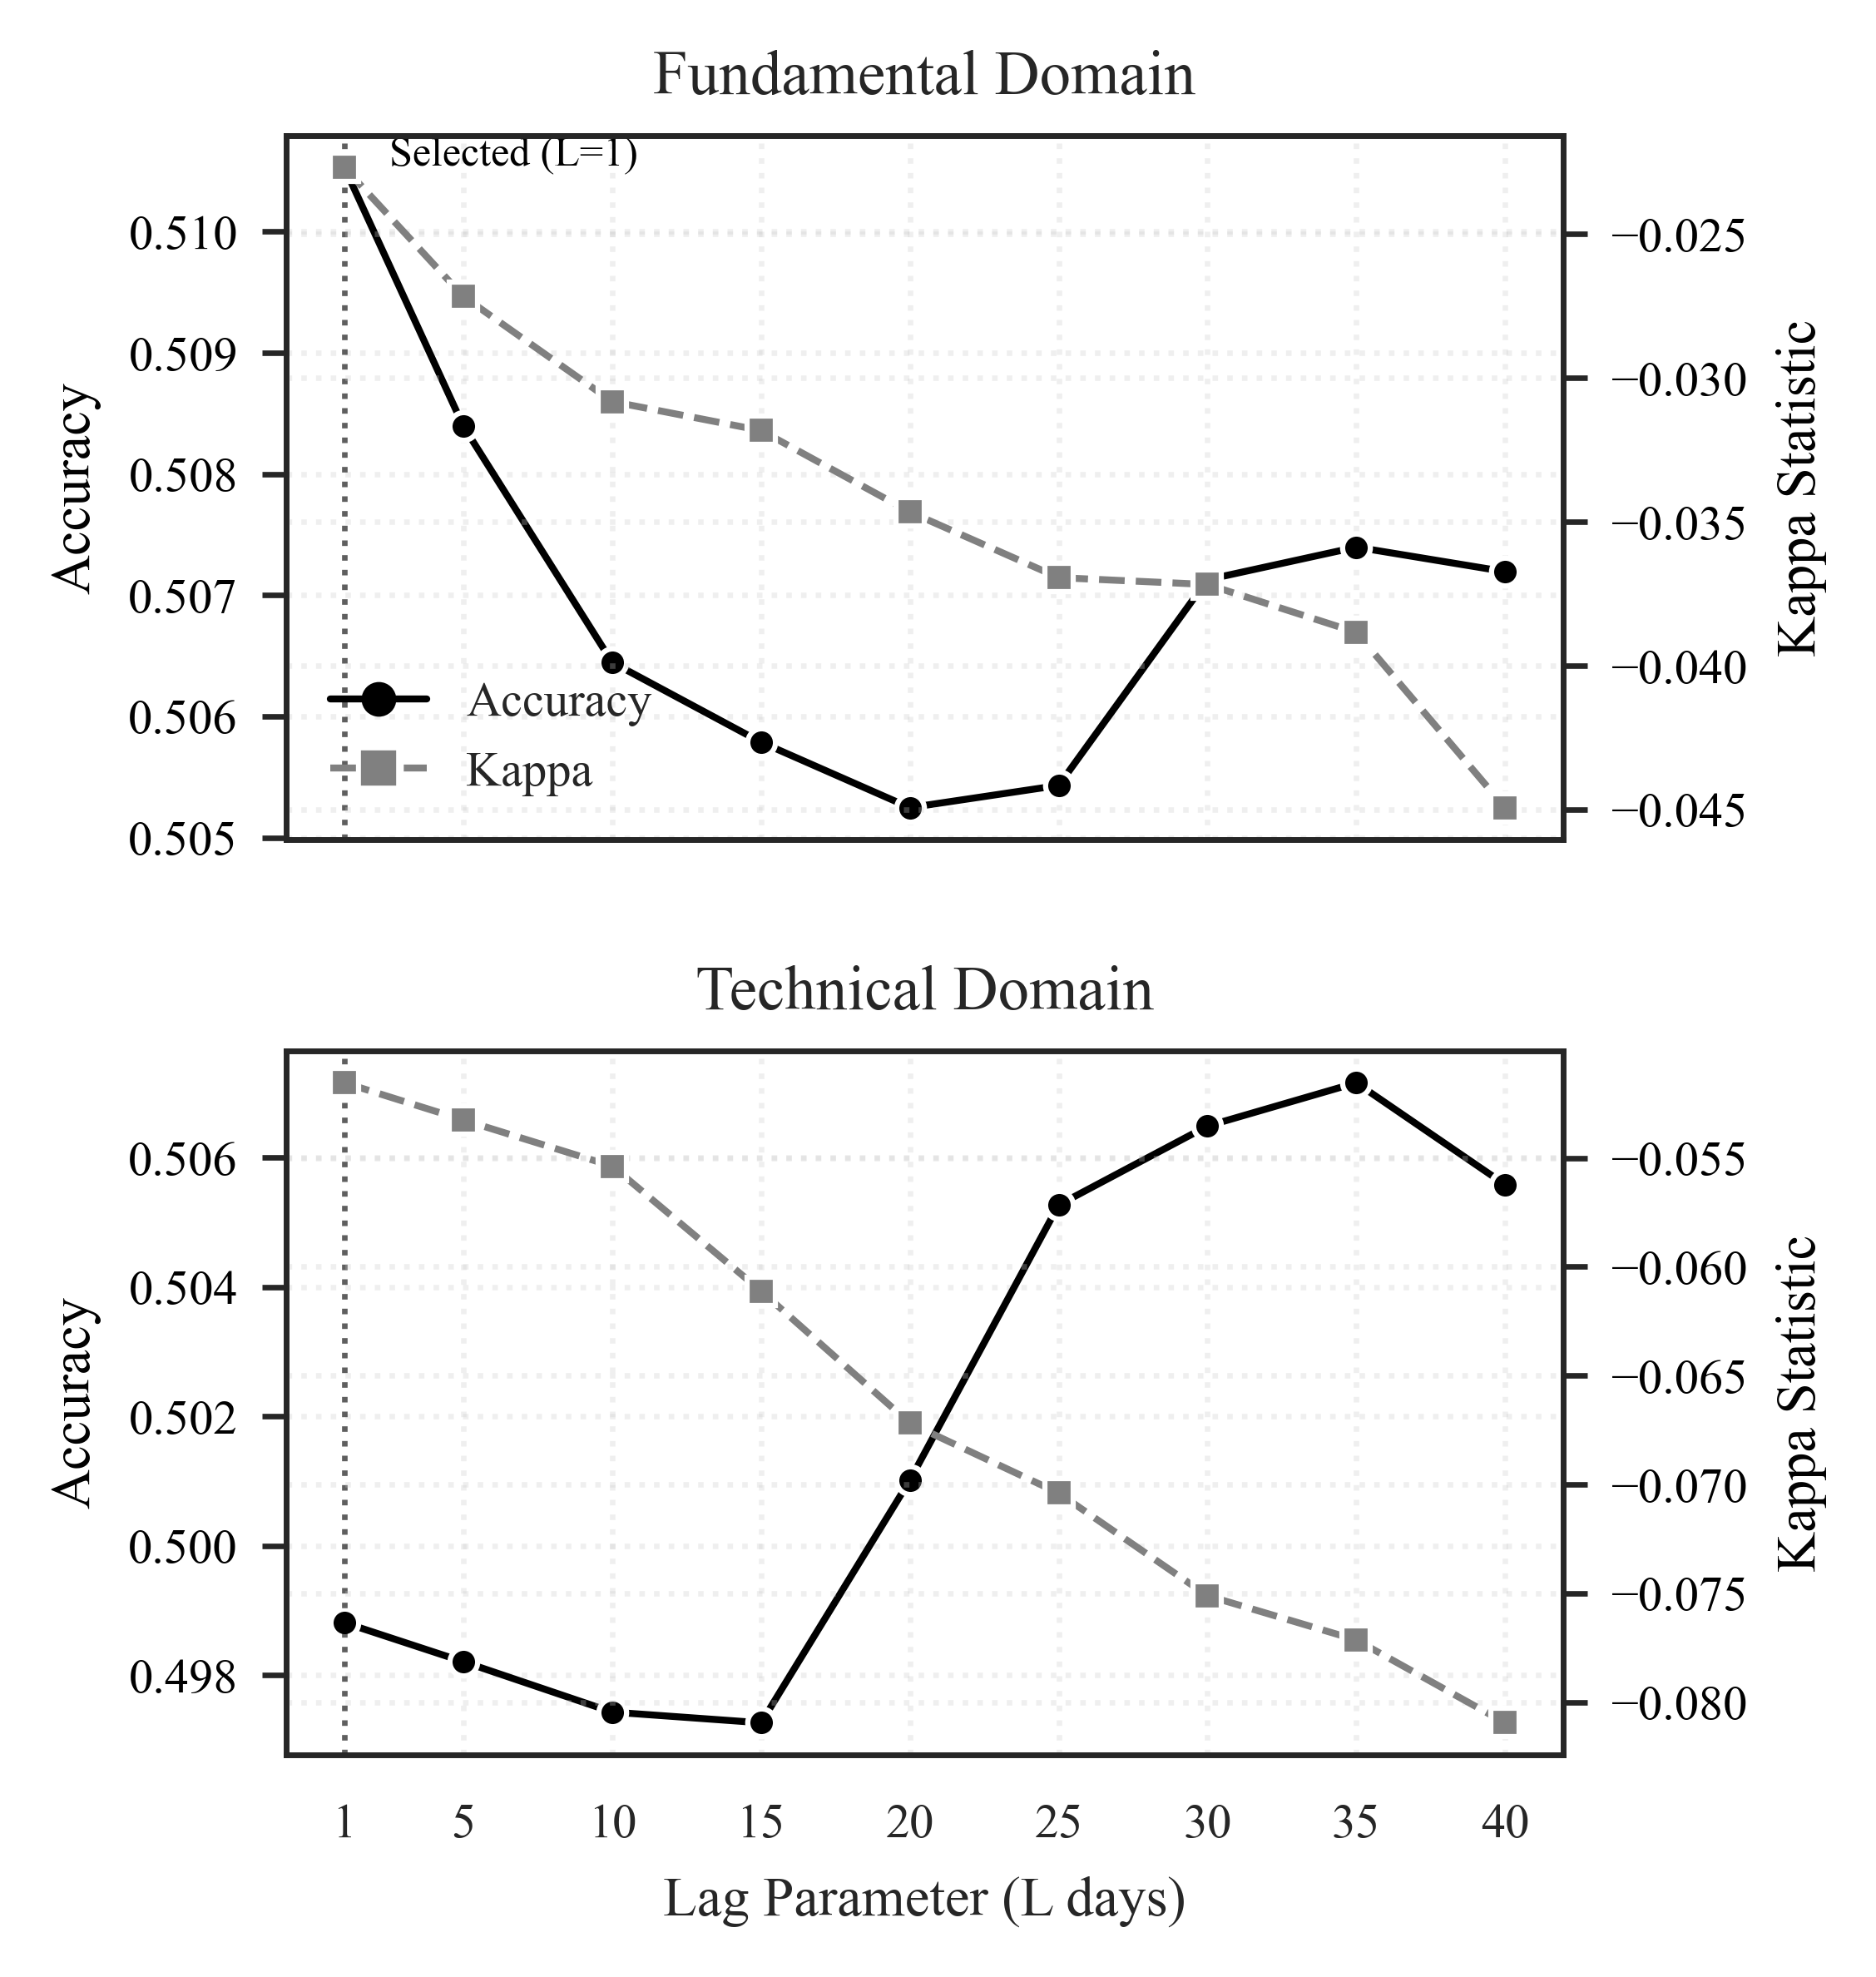

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.font_manager as fm

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atrasos = [1, 5, 10, 15, 20, 25, 30, 35, 40]
caminho_base = 'resultados'
caminho_vmob = '/home/jjos/profit_performance/valor_mobiliario.csv' # Verifique este caminho
LAG_SELECIONADO = 1 

# Listas para armazenar dados
dados_agregados_plot = []   # Para o gráfico
dados_relatorio = []        # Para a tabela CSV

# Configuração de Fonte (Times New Roman)
caminho_fonte = os.path.expanduser('~/.local/share/fonts/times.ttf') 
if not os.path.exists(caminho_fonte):
    caminho_fonte = os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf')

try:
    fm.fontManager.addfont(caminho_fonte)
    propriedade = fm.FontProperties(fname=caminho_fonte)
    nome_familia = propriedade.get_name()
except Exception:
    nome_familia = 'serif'

# Estilo IEEE
cor_acc = 'black'       
cor_kap = 'black'
estilo_acc = '-'
estilo_kap = '--'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': [nome_familia],
    'font.size': 8,              
    'axes.labelsize': 8,         
    'axes.titlesize': 9,         
    'legend.fontsize': 7,        
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,           
    'lines.linewidth': 1.0,      
    'lines.markersize': 4,       
    'axes.grid': True,           
    'grid.alpha': 0.3,           
    'grid.linestyle': ':'
})

mapa_nomes = {'fund': 'Fundamental Domain', 'nao_fund': 'Technical Domain'}

# ==============================================================================
# 2. PROCESSAMENTO (LOOP PRINCIPAL)
# ==============================================================================
print(f"Processando dados dos lags...")

if os.path.exists(caminho_base):
    for atraso in atrasos:
        nome_arquivo = f'resultados_{modelo}_atraso_{atraso}.csv'
        caminho_completo = os.path.join(caminho_base, nome_arquivo)
        
        try:
            if not os.path.exists(caminho_completo): continue
            
            df = pd.read_csv(caminho_completo)
            
            # --- FILTRAGEM DE ATIVOS (CRUCIAL) ---
            try:
                # Carregar filtro de liquidez/ano se necessário
                if os.path.exists(caminho_vmob):
                    df_vmob = pd.read_csv(caminho_vmob)
                    if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
                        df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

                    papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
                    
                    df = df[df['base'].isin(papeis)]
                    df = df[~df['base'].isin(['LEVE3'])] # Exclusão explícita
                
                # Conta quantos ativos únicos sobraram neste Lag após o filtro
                qtd_ativos = df['base'].nunique()
                
            except Exception as e:
                print(f"Erro no filtro (Lag {atraso}): {e}")
                qtd_ativos = df['base'].nunique()

            # --- COLETA DE DADOS PARA GRÁFICO E RELATÓRIO ---
            for cat_codigo, cat_nome in mapa_nomes.items():
                df_filtrado = df[df['categoria'] == cat_codigo]
                
                if not df_filtrado.empty:
                    acc_mean = df_filtrado['Accuracy'].mean()
                    kap_mean = df_filtrado['Kappa'].mean()
                    
                    # 1. Dados para o Plot (Formato Simples)
                    dados_agregados_plot.append({
                        'Lag_Int': atraso,
                        'Domain': cat_nome,
                        'Accuracy': acc_mean,
                        'Kappa': kap_mean
                    })
                    
                    # 2. Dados para o Relatório (Detalhado)
                    dados_relatorio.append({
                        'Lag': atraso,
                        'Domain': cat_nome,
                        'Ativos_Count': qtd_ativos,  # Número de ativos usados
                        'Accuracy_Exact': acc_mean,
                        'Kappa_Exact': kap_mean
                    })

        except Exception as e:
            print(f"Erro ao processar arquivo {nome_arquivo}: {e}")

# (Bloco de dados simulados omitido para brevidade, mas deve seguir a mesma lógica se usado)

# ==============================================================================
# 3. GERAÇÃO DO RELATÓRIO TABULAR (O QUE VOCÊ PEDIU)
# ==============================================================================
df_relatorio = pd.DataFrame(dados_relatorio)

if not df_relatorio.empty:
    # Ordenar
    df_relatorio = df_relatorio.sort_values(['Domain', 'Lag'])
    
    # Reordenar colunas
    cols = ['Domain', 'Lag', 'Ativos_Count', 'Accuracy_Exact', 'Kappa_Exact']
    df_relatorio = df_relatorio[cols]
    
    print("\n" + "="*80)
    print("RELATÓRIO DETALHADO: ACCURACY E KAPPA POR LAG")
    print("="*80)
    # Exibe com 4 casas decimais
    print(df_relatorio.to_string(index=False, float_format="%.5f"))
    
    df_relatorio.to_csv('relatorio_lag_exato.csv', index=False, float_format="%.5f")
    print("\nRelatório salvo em: relatorio_lag_exato.csv")
else:
    print("Nenhum dado encontrado para gerar o relatório.")


# ==============================================================================
# 4. PLOTAGEM (Seu código original de plotagem segue aqui com dados_agregados_plot)
# ==============================================================================
if dados_agregados_plot:
    df_plot = pd.DataFrame(dados_agregados_plot).sort_values('Lag_Int')
    
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(3.8, 4.0), sharex=True)

    def plot_ieee_dual_axis(ax_primary, data, title):
        sns.lineplot(data=data, x='Lag_Int', y='Accuracy', ax=ax_primary, 
                     color=cor_acc, marker='o', linestyle=estilo_acc, 
                     legend=False, ci=None) 
        
        ax_primary.set_ylabel('Accuracy', color=cor_acc)
        ax_primary.tick_params(axis='y', labelcolor=cor_acc)
        
        ax_secondary = ax_primary.twinx() 
        sns.lineplot(data=data, x='Lag_Int', y='Kappa', ax=ax_secondary, 
                     color="grey", marker='s', linestyle=estilo_kap, 
                     legend=False, ci=None)
        
        ax_secondary.set_ylabel('Kappa Statistic', color=cor_kap)
        ax_secondary.tick_params(axis='y', labelcolor=cor_kap)
        
        ax_primary.set_title(title, pad=6)
        ax_primary.axvline(x=LAG_SELECIONADO, color='black', linestyle=':', linewidth=0.8, alpha=0.6)
        
        return ax_secondary

    data_fund = df_plot[df_plot['Domain'] == 'Fundamental Domain']
    plot_ieee_dual_axis(ax_top, data_fund, 'Fundamental Domain')
    
    y_limits = ax_top.get_ylim()
    ax_top.text(LAG_SELECIONADO + 1.5, y_limits[1], f"Selected (L={LAG_SELECIONADO})", 
                color='black', fontsize=6, va='top', ha='left')

    data_tech = df_plot[df_plot['Domain'] == 'Technical Domain']
    plot_ieee_dual_axis(ax_bottom, data_tech, 'Technical Domain')

    ax_bottom.set_xlabel('Lag Parameter (L days)')
    ax_bottom.set_xticks(atrasos)

    legend_elements = [
        Line2D([0], [0], color=cor_acc, lw=1, marker='o', markersize=4, label='Accuracy'),
        Line2D([0], [0], color="grey", lw=1, linestyle=estilo_kap, marker='s', markersize=4, label='Kappa')
    ]
    ax_top.legend(handles=legend_elements, loc='lower left', frameon=False, 
                  bbox_to_anchor=(0, 0), fontsize=7, ncol=1)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) 
    
    if not os.path.exists('figuras'): os.makedirs('figuras')
    plt.savefig('figuras/lag_sensitivity.pdf', format='pdf', dpi=600, bbox_inches='tight')
    plt.show()

Processando arquivos...


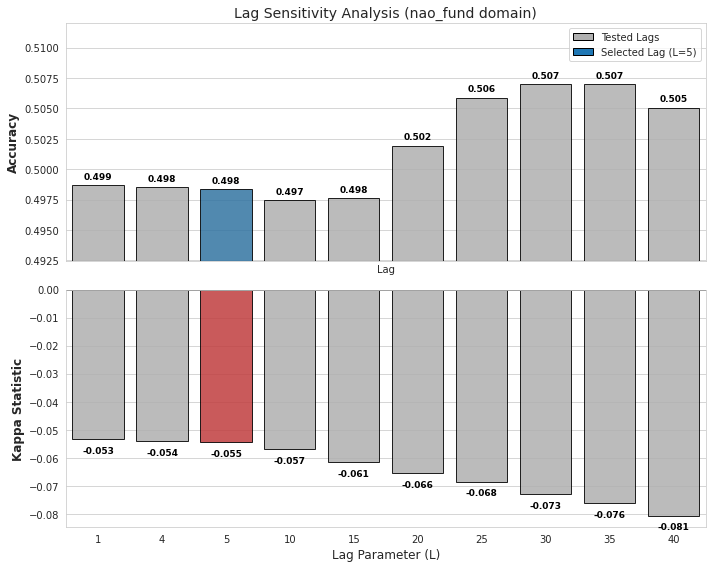

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
categoria = 'nao_fund' # Ou 'nao_fund'
atrasos = [1, 5, 10, 15, 20, 25, 30, 35, 40]
caminho_base = 'resultados'

# Defina qual Lag você quer destacar (pintar de outra cor)
lag_destaque = 1 

dados_agregados = []

# ==============================================================================
# PROCESSAMENTO DE DADOS (Igual ao anterior)
# ==============================================================================
print("Processando arquivos...")
for atraso in atrasos:
    try:
        arquivo = f'{caminho_base}/resultados_{modelo}_atraso_{atraso}.csv'
        df = pd.read_csv(arquivo)
        df_filtrado = df[df['categoria'] == categoria]
        
        if df_filtrado.empty:
            continue

        media_acc = df_filtrado['Accuracy'].mean()
        media_kappa = df_filtrado['Kappa'].mean()
        
        dados_agregados.append({
            'Lag': str(atraso), # Convertendo para string para o eixo X ficar categórico
            'Accuracy': media_acc,
            'Kappa': media_kappa,
            'Lag_Int': atraso
        })
        
    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")

df_plot = pd.DataFrame(dados_agregados)
df_plot = df_plot.sort_values('Lag_Int')

# ==============================================================================
# PLOTAGEM COM BARRAS DESTACADAS
# ==============================================================================

# Configura o estilo
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Lógica de Cores para Destacar L=5 ---
# Cria uma lista de cores: Cinza para todos, Azul Forte para o Lag=5
cores_acc = ['#B0B0B0' if x != lag_destaque else '#1f77b4' for x in df_plot['Lag_Int']]
cores_kappa = ['#B0B0B0' if x != lag_destaque else '#d62728' for x in df_plot['Lag_Int']]

# --- Gráfico 1: Acurácia ---
sns.barplot(data=df_plot, x='Lag', y='Accuracy', palette=cores_acc, ax=ax1, edgecolor='black', alpha=0.85)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title(f'Lag Sensitivity Analysis ({categoria} domain)', fontsize=14)
ax1.set_ylim(bottom=df_plot['Accuracy'].min() - 0.005, top=df_plot['Accuracy'].max() + 0.005) # Zoom no eixo Y

# Anotações (Números em cima das barras)
for i, v in enumerate(df_plot['Accuracy']):
    ax1.text(i, v + 0.0005, f'{v:.3f}', color='black', ha='center', fontsize=9, fontweight='bold')

# --- Gráfico 2: Kappa ---
sns.barplot(data=df_plot, x='Lag', y='Kappa', palette=cores_kappa, ax=ax2, edgecolor='black', alpha=0.85)
ax2.set_ylabel('Kappa Statistic', fontsize=12, fontweight='bold')
ax2.set_xlabel('Lag Parameter (L)', fontsize=12)

# Linha zero para o Kappa (caso haja valores negativos)
ax2.axhline(0, color='black', linewidth=1, linestyle='-')

# Anotações
for i, v in enumerate(df_plot['Kappa']):
    # Ajusta a posição do texto se o valor for negativo
    offset = 0.002 if v >= 0 else -0.005
    ax2.text(i, v + offset, f'{v:.3f}', color='black', ha='center', fontsize=9, fontweight='bold')

# Adiciona uma legenda manual para explicar o destaque
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#B0B0B0', edgecolor='black', label='Tested Lags'),
                   Patch(facecolor='#1f77b4', edgecolor='black', label='Selected Lag (L=5)')]
ax1.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()